# Customer Churn Prediction — ChurnGuard: Technical Analysis Notebook
## End-to-End Pipeline: Diagnosis, Modelling & Validation

**Domain:** E-commerce / subscription (account-level churn)

**Scope note:** This notebook is a single, de-duplicated, end-to-end pipeline covering problem framing, data quality review, exploratory analysis, feature engineering, model building, tuning, and final model selection. Data cleaning happens **once**, at the top, and every later step — EDA, feature engineering,
modelling — builds on that same cleaned dataframe. Nothing here re-cleans or re-derives what an earlier
cell already produced.

## 1. Introduction

### 1.1 The business problem
ChurnGuard operates an e-commerce/subscription business where the **account**, not the individual
customer, is the billing unit — a single account can have multiple customers tagged to it
(`Account_user_count`). Today, roughly **1 in 6 accounts (16.8%) churns**. That number alone is not the
real problem: the real problem is that reactive retention — contacting a customer only after they have
already cancelled — is largely ineffective, and because one account can carry several customers, each
churned account can mean losing several customers and their combined recurring revenue at once.

### 1.2 Why this needs solving now
Two business constraints make this urgent and specific, not a generic "reduce churn" exercise:
1. **Cost asymmetry.** Acquiring a new account costs materially more than retaining an existing one, and
   any retention offer built on top of this analysis must be **economically defensible** — its cost must
   be smaller than the expected revenue saved, or Finance/Revenue Assurance will not approve it. A
   blanket, company-wide discount is not viable; the response has to be targeted.
2. **No early-warning system exists today.** Without a model that scores active accounts on churn risk
   *before* they leave, Customer Success/Retention teams can only react after the relationship is
   already lost.

### 1.3 What this notebook does about it
This notebook is structured in two connected halves that answer two different questions:
- **Diagnosis (Sections 2–5):** Where does churn concentrate, and why? Clean the raw export, then use
  univariate, bivariate, and multivariate analysis to surface the handful of signals that actually
  separate accounts that leave from accounts that stay.
- **Prediction & Action (Sections 6–9):** Can those same signals be combined into a single score precise
  enough to act on *individual* accounts — not just describe the problem, but flag who is at risk, catch
  it early, and hand the business a short, targeted, defensible priority list.

## 2. Setup and Data Overview

In [1]:
# --- Standard toolkit for this notebook ---
# numpy/pandas: data wrangling. matplotlib/seaborn: charts. sklearn/imblearn/xgboost: modelling.
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")  # keep the final, submitted notebook free of noisy library warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                      RandomizedSearchCV, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Display options — purely cosmetic, make wide tables/columns readable in this notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42  # fixed seed used everywhere below so every split/shuffle/fit is reproducible

### 2.1 Loading the data
The workbook has two sheets: a data dictionary ("Meta Data") describing every field, and the actual
account-level table ("Data for DSBA"). We load both — the dictionary is used once, to sanity-check column
meanings; the account table (`df`) is what the rest of the notebook works from.

In [2]:
file_path = "Customer Churn Data.xlsx"

meta = pd.read_excel(file_path, sheet_name="Meta Data")
df = pd.read_excel(file_path, sheet_name="Data for DSBA")

# Watch this number every time the notebook is re-run on a refreshed export: if row/column
# counts change, every percentage quoted later in this notebook needs to be recalculated, not
# just carried forward from this run.
print("Data shape:", df.shape)
df.head()

Data shape: (11260, 19)


,AccountID,Churn,Tenure,City_Tier,CC_Contacted_LY,Payment,Gender,Service_Score,Account_user_count,account_segment,CC_Agent_Score,Marital_Status,rev_per_month,Complain_ly,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,Login_device
0,20000,1,4,3.0,6.0,Debit Card,Female,3.0,3,Super,2.0,Single,9,1.0,11,1,5,159.93,Mobile
1,20001,1,0,1.0,8.0,UPI,Male,3.0,4,Regular Plus,3.0,Single,7,1.0,15,0,0,120.9,Mobile
2,20002,1,0,1.0,30.0,Debit Card,Male,2.0,4,Regular Plus,3.0,Single,6,1.0,14,0,3,NaN,Mobile
3,20003,1,0,3.0,15.0,Debit Card,Male,2.0,4,Super,5.0,Single,8,0.0,23,0,3,134.07,Mobile
4,20004,1,0,1.0,12.0,Credit Card,Male,2.0,3,Regular Plus,5.0,Single,3,0.0,11,1,3,129.6,Mobile


In [3]:
# Tidy the glossary sheet down to a clean two-column table (Variable, Description) — as
# exported it has decorative blank columns around the real content.
meta = meta.dropna(axis=1, how="all").iloc[:, -2:]
meta.columns = ["Variable", "Description"]
meta = meta.dropna(subset=["Variable"]).reset_index(drop=True)
meta

,Variable,Description
0,Variable,Description
1,AccountID,account unique identifier
2,Churn,account churn flag (Target)
3,Tenure,Tenure of account
4,City_Tier,Tier of primary customer's city
5,CC_Contacted_L12m,How many times all the customers of the accoun...
6,Payment,Preferred Payment mode of the customers in the...
7,Gender,Gender of the primary customer of the account
8,Service_Score,Satisfaction score given by customers of the a...
9,Account_user_count,Number of customers tagged with this account


In [4]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()
# What to look for above: any column whose non-null count is well below 11,260 has missing
# values; any column that "should" be numeric but is listed as dtype object almost certainly
# contains a stray non-numeric character mixed in with real numbers — both are addressed below.

Rows: 11260, Columns: 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11260 entries, 0 to 11259
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AccountID                11260 non-null  int64  
 1   Churn                    11260 non-null  int64  
 2   Tenure                   11158 non-null  object 
 3   City_Tier                11148 non-null  float64
 4   CC_Contacted_LY          11158 non-null  float64
 5   Payment                  11151 non-null  object 
 6   Gender                   11152 non-null  object 
 7   Service_Score            11162 non-null  float64
 8   Account_user_count       11148 non-null  object 
 9   account_segment          11163 non-null  object 
 10  CC_Agent_Score           11144 non-null  float64
 11  Marital_Status           11048 non-null  object 
 12  rev_per_month            11158 non-null  object 
 13  Complain_ly              10903 non-null  float64
 1

In [5]:
print("Duplicate AccountID rows:", df["AccountID"].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())
# Zero duplicates on both counts confirms AccountID is a genuine unique account identifier —
# it carries no predictive value on its own and will be dropped before modelling (Section 5).

Duplicate AccountID rows: 0
Duplicate full rows: 0


## 3. Data Cleaning and Pre-processing

This section identifies and treats **three distinct data-quality issues** found in the raw export, and
explains the reasoning behind each treatment choice — not just what was done, but why that option was
preferred over the obvious alternatives (dropping rows, leaving values as-is, etc.).

In [6]:
object_cols = df.select_dtypes(include="object").columns.tolist()
for c in object_cols:
    # For every text-typed column, list any value that does NOT look like a plain number —
    # this surfaces exactly which stray characters are contaminating otherwise-numeric fields.
    non_numeric_like = [v for v in df[c].dropna().unique()
                         if not str(v).replace(".", "", 1).replace("-", "", 1).strip().isdigit()]
    print(f"{c}: {df[c].nunique()} unique values | sample non-numeric-looking values: {non_numeric_like[:8]}")

Tenure: 38 unique values | sample non-numeric-looking values: ['#']
Payment: 5 unique values | sample non-numeric-looking values: ['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
Gender: 4 unique values | sample non-numeric-looking values: ['Female', 'Male', 'F', 'M']
Account_user_count: 7 unique values | sample non-numeric-looking values: ['@']
account_segment: 7 unique values | sample non-numeric-looking values: ['Super', 'Regular Plus', 'Regular', 'HNI', 'Regular +', 'Super Plus', 'Super +']
Marital_Status: 3 unique values | sample non-numeric-looking values: ['Single', 'Divorced', 'Married']
rev_per_month: 59 unique values | sample non-numeric-looking values: ['+']
rev_growth_yoy: 20 unique values | sample non-numeric-looking values: ['$']
coupon_used_for_payment: 20 unique values | sample non-numeric-looking values: ['#', '$', '*']
Day_Since_CC_connect: 24 unique values | sample non-numeric-looking values: ['$']
cashback: 5693 unique values | sample non-numeric

**Observation:** several columns that should be numeric (`Tenure`, `Account_user_count`, `rev_per_month`,
`rev_growth_yoy`, `coupon_used_for_payment`, `Day_Since_CC_connect`, `cashback`) are stored as `object`
dtype because a handful of stray junk characters (`#`, `@`, `+`, `$`, `*`, `&&&&`) are mixed in with
genuine numeric entries — almost certainly export/data-entry artefacts, not real values.
`Login_device` also contains the literal string `&&&&` as a corrupted category.

**Why this needs fixing, not ignoring:** left as-is, a column like `Tenure` would be treated as a
categorical/text field by any downstream model, silently discarding all of its numeric signal — including
the single strongest churn driver in this dataset (Section 4).

In [7]:
# --- Step 1: junk placeholder tokens -> NaN ---
# These characters are not real data; converting them to NaN lets us treat them as missing
# values and impute properly, rather than leaving a literal "#" sitting inside a numeric column.
junk_tokens = ["#", "@", "+", "$", "*", "&&&&"]
df_clean = df.replace(junk_tokens, np.nan).infer_objects(copy=False)

# --- Step 2: cast the numeric-but-mis-typed columns back to real numeric dtype ---
numeric_fix_cols = [
    "Tenure", "Account_user_count", "rev_per_month", "rev_growth_yoy",
    "coupon_used_for_payment", "Day_Since_CC_connect", "cashback",
]
for c in numeric_fix_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
    # Tweak: errors="coerce" turns any value that still isn't a clean number into NaN instead
    # of raising an error — safer for a one-off export than crashing the whole pipeline.

# --- Step 3: standardise duplicate category labels that mean the same thing ---
# "M"/"F" and "Male"/"Female" are the same two genders written two different ways; "Regular +"
# and "Regular Plus" are the same segment. Left unmerged, every later groupby would silently
# split one real category into two, understating its true size and churn rate.
df_clean["Gender"] = df_clean["Gender"].replace({"M": "Male", "F": "Female"})
df_clean["account_segment"] = df_clean["account_segment"].replace(
    {"Regular +": "Regular Plus", "Super +": "Super Plus"}
)

print("Dtypes after cleaning:")
print(df_clean.dtypes)

Dtypes after cleaning:
AccountID                    int64
Churn                        int64
Tenure                     float64
City_Tier                  float64
CC_Contacted_LY            float64
Payment                     object
Gender                      object
Service_Score              float64
Account_user_count         float64
account_segment             object
CC_Agent_Score             float64
Marital_Status              object
rev_per_month              float64
Complain_ly                float64
rev_growth_yoy             float64
coupon_used_for_payment    float64
Day_Since_CC_connect       float64
cashback                   float64
Login_device                object
dtype: object


In [8]:
print("Gender categories:", df_clean["Gender"].unique())
print("account_segment categories:", df_clean["account_segment"].unique())
print("Login_device categories:", df_clean["Login_device"].unique())
# Confirms the label merge worked: each of these should now show only its genuine categories
# (Login_device's corrupted "&&&&" entry has already become NaN via Step 1 above).

Gender categories: ['Female' 'Male' nan]
account_segment categories: ['Super' 'Regular Plus' 'Regular' 'HNI' nan 'Super Plus']
Login_device categories: ['Mobile' 'Computer' nan]


### 3.1 Missing value treatment

In [9]:
missing_pct = (df_clean.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct

rev_per_month              7.02
Login_device               6.75
cashback                   4.20
Account_user_count         3.94
Day_Since_CC_connect       3.18
Complain_ly                3.17
Tenure                     1.94
Marital_Status             1.88
CC_Agent_Score             1.03
City_Tier                  0.99
Payment                    0.97
Gender                     0.96
CC_Contacted_LY            0.91
Service_Score              0.87
account_segment            0.86
coupon_used_for_payment    0.03
rev_growth_yoy             0.03
dtype: float64

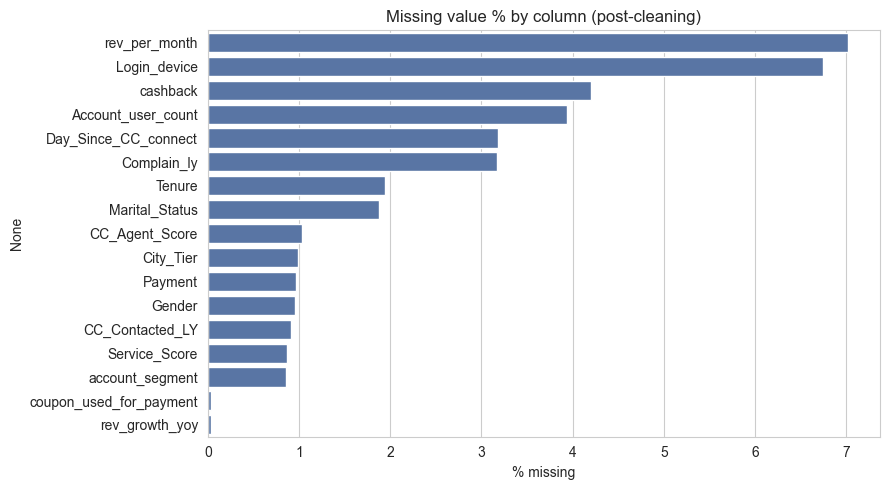

In [10]:
plt.figure(figsize=(9, 5))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#4C72B0")
plt.xlabel("% missing")
plt.title("Missing value % by column (post-cleaning)")
plt.tight_layout()
plt.show()

**Approach and why:** after cleaning, almost every column carries some missing values — a mix of genuine
blanks in the source export and the junk tokens just converted to `NaN`. None of the missingness rates are
extreme (all comfortably below 10%), so we **impute rather than drop rows** — dropping would discard an
otherwise-complete record just because one of its 19 fields is blank, silently biasing whichever accounts
happen to remain.

- **Continuous columns → median.** Most are right-skewed (confirmed in Section 5.2), and the median is
  robust to that skew — the mean would be pulled toward the skewed tail and misrepresent a "typical"
  account.
- **Categorical columns → mode** (most frequent category) — the standard, conservative choice when a
  category is missing at a low rate.
- `Churn` (the target) has zero missing values, so no target-side imputation is ever needed.

In [11]:
continuous_cols = [
    "Tenure", "CC_Contacted_LY", "rev_per_month", "rev_growth_yoy",
    "coupon_used_for_payment", "Day_Since_CC_connect", "cashback",
]
count_like_cols = ["City_Tier", "Service_Score", "Account_user_count", "CC_Agent_Score", "Complain_ly"]
categorical_cols = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device"]

for c in continuous_cols + count_like_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())
    # Tweak: switch to .mean() here if a future analyst decides these are no longer skewed
    # enough to justify the median — check Section 5.2's skew numbers again first.

for c in categorical_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])

print("Remaining missing values:", df_clean.isnull().sum().sum())

Remaining missing values: 0


### 3.2 Outlier detection and treatment

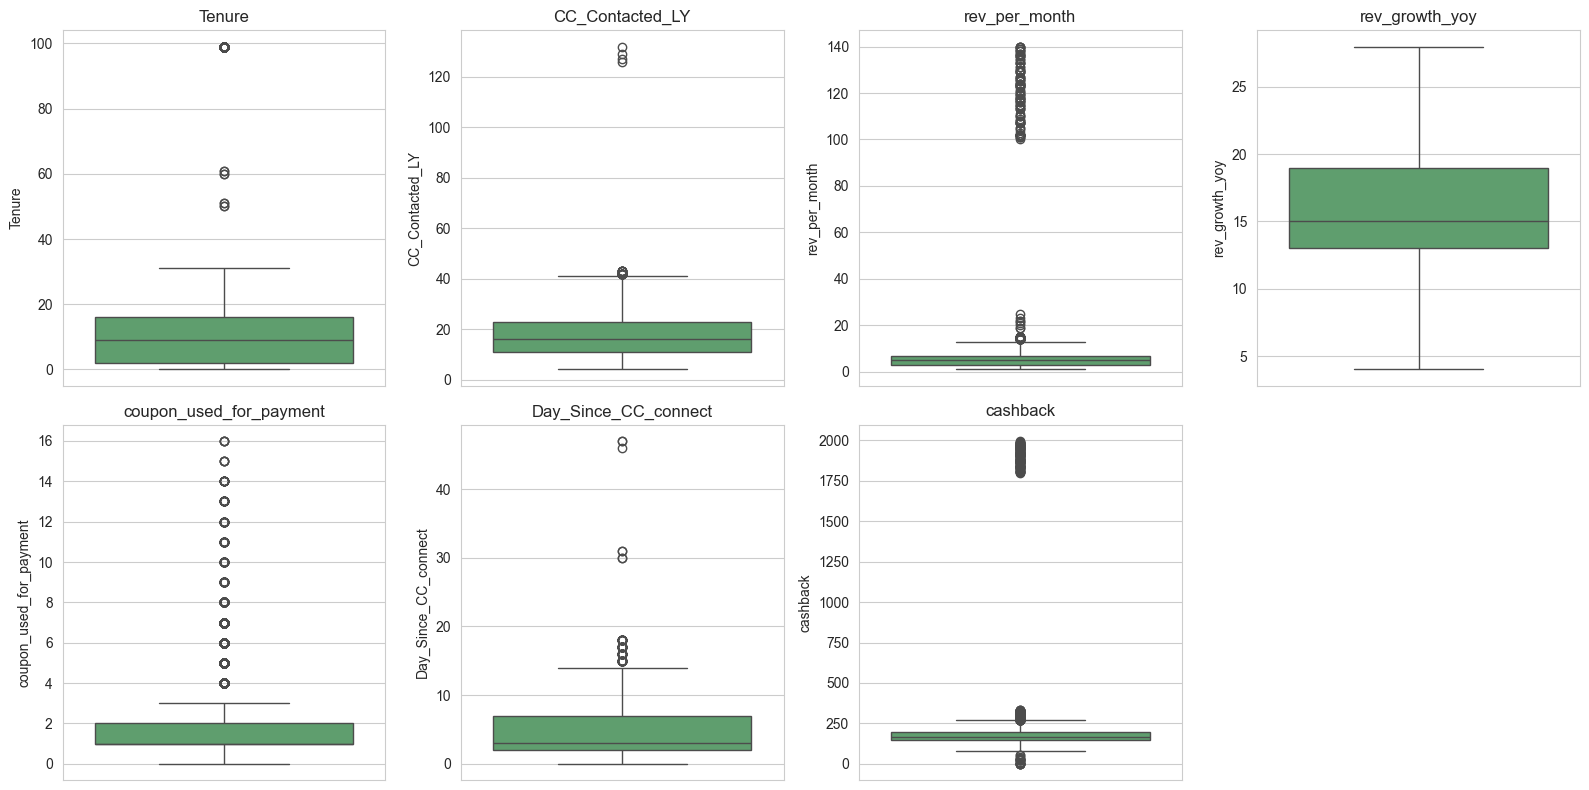

In [12]:
plt.figure(figsize=(16, 8))
for i, c in enumerate(continuous_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df_clean[c], color="#55A868")
    plt.title(c)
plt.tight_layout()
plt.show()

Two distinct patterns show up in these boxplots, and they call for **two different treatments** — this is
the one genuinely judgemental step in the whole cleaning process, worth being explicit about:

1. **`Tenure` has a suspicious spike at exactly 99**, isolated from the real distribution by a visible
   gap (the next-highest genuine values sit in the 50s–60s). 131 accounts sharing one exact integer value,
   with nothing in between, is not how a continuous, organically-earned tenure would behave — it is the
   classic signature of a **sentinel/placeholder value** (e.g. "unknown" or "capped at export"), not 131
   real 99-month-old accounts. **Treatment: recode to missing, then re-impute with the median** — the
   same honest treatment as any other missing value, not a fabricated number.
2. **`rev_per_month`, `cashback`, `CC_Contacted_LY`, and `Day_Since_CC_connect`** are genuinely skewed —
   these look like real (if extreme) account behaviour, such as high-value or highly-engaged accounts,
   not data errors. **Treatment: winsorize (cap) at the 1st/99th percentile** rather than delete the row —
   this keeps the account's other 18 fields intact while limiting how much leverage one extreme value can
   exert on an average or a model later.

In [13]:
# Tenure == 99 is treated as a placeholder/data-quality issue, not a genuine outlier
print("Accounts with Tenure == 99:", (df_clean["Tenure"] == 99).sum())

df_clean.loc[df_clean["Tenure"] == 99, "Tenure"] = np.nan
df_clean["Tenure"] = df_clean["Tenure"].fillna(df_clean["Tenure"].median())

Accounts with Tenure == 99: 131


In [14]:
# Winsorize the remaining genuinely skewed continuous columns at the 1st/99th percentile.
# Why 1st/99th and not the stricter 1.5xIQR rule used in the boxplots above: 1.5xIQR would
# flag far more points (as much as ~12% of some columns) as "abnormal" — over-correcting for
# what is likely just genuine skew, not error. Percentile capping only touches the most
# extreme ~2% combined, a deliberately conservative, easier-to-defend middle ground.
winsorize_cols = ["rev_per_month", "cashback", "CC_Contacted_LY", "Day_Since_CC_connect"]

for c in winsorize_cols:
    lower, upper = df_clean[c].quantile([0.01, 0.99])
    # Tweak: widen to [0.001, 0.999] to cap almost nothing, or tighten to [0.05, 0.95] to cap
    # much more aggressively — 0.01/0.99 is the deliberately conservative middle ground used here.
    n_capped = ((df_clean[c] < lower) | (df_clean[c] > upper)).sum()
    df_clean[c] = df_clean[c].clip(lower, upper)
    print(f"{c}: capped to [{lower:.1f}, {upper:.1f}] — {n_capped} values adjusted")

rev_per_month: capped to [1.0, 16.6] — 113 values adjusted
cashback: capped to [118.8, 329.3] — 225 values adjusted
CC_Contacted_LY: capped to [6.0, 40.0] — 80 values adjusted
Day_Since_CC_connect: capped to [0.0, 15.0] — 93 values adjusted


### 3.3 New variables (feature engineering)
Two lightweight, business-interpretable features are added — no columns are removed at this stage, since
every remaining raw field still carries some signal worth testing in Section 6.

In [15]:
df_clean["rev_per_user"] = df_clean["rev_per_month"] / df_clean["Account_user_count"]
# Why: rev_per_month alone conflates "how much this account is worth" with "how many people
# are on it" — normalising by user count isolates the per-customer revenue contribution.

df_clean["Tenure_Group"] = pd.cut(
    df_clean["Tenure"],
    bins=[-0.1, 3, 6, 12, 24, df_clean["Tenure"].max()],
    labels=["0-3", "3-6", "6-12", "12-24", "24+"],
)
# Why: a binned tenure is easier to read in a chart and easier to turn into a campaign rule
# ("target 0-3 months") than a raw floating-point threshold — it does not add new information
# beyond the raw Tenure column, it just repackages it for communication (see Section 5).

df_clean[["rev_per_month", "Account_user_count", "rev_per_user", "Tenure", "Tenure_Group"]].head()

,rev_per_month,Account_user_count,rev_per_user,Tenure,Tenure_Group
0,9.0,3.0,3.00,4.0,3-6
1,7.0,4.0,1.75,0.0,0-3
2,6.0,4.0,1.50,0.0,0-3
3,8.0,4.0,2.00,0.0,0-3
4,3.0,3.0,1.00,0.0,0-3


## 4. Exploratory Data Analysis and Business Implication

This section works through **univariate → bivariate → multivariate** analysis, combining visual charts
with the non-visual (tabular/numeric) evidence behind them, and closes each layer with what it means for
the business — not just what the data shows.

### 4.1 Univariate analysis — the target variable

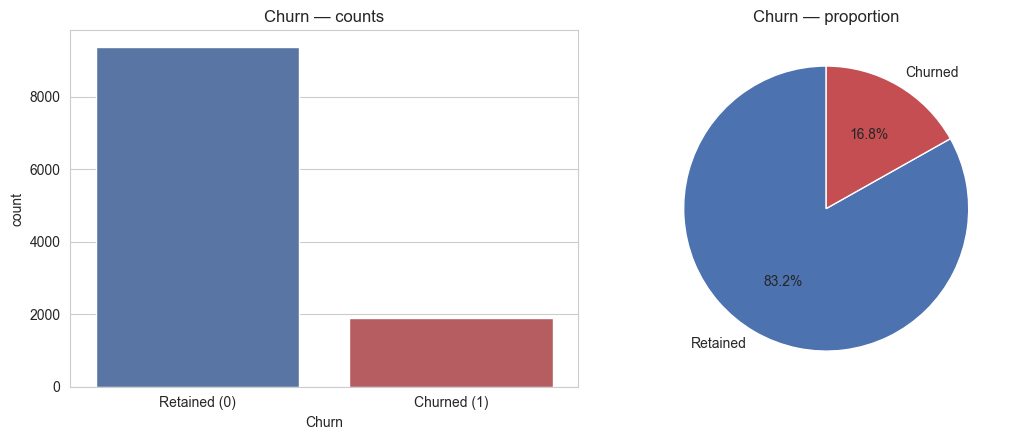

Churn
0    83.2
1    16.8
Name: proportion, dtype: float64


In [16]:
churn_counts = df_clean["Churn"].value_counts()
churn_pct = df_clean["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.countplot(x="Churn", data=df_clean, ax=axes[0], palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Churn — counts")
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"])

axes[1].pie(churn_pct, labels=["Retained", "Churned"], autopct="%1.1f%%",
            colors=["#4C72B0", "#C44E52"], startangle=90)
axes[1].set_title("Churn — proportion")
plt.tight_layout()
plt.show()

print(churn_pct.round(1))  # non-visual confirmation of the same split shown in the chart above

**Observation (visual + non-visual):** the target is **imbalanced — 83.2% retained vs. 16.8% churned**.
**Business implication:** a model (or a manager) that assumes "most accounts are fine" is not wrong on
average, but is useless for the specific task at hand — finding the 1-in-6 accounts worth intervening on.
This directly shapes the modelling strategy in Section 6 (class-weighting/SMOTE, evaluated on recall and
F1 for the churn class rather than plain accuracy).

### 4.2 Univariate analysis — continuous variables

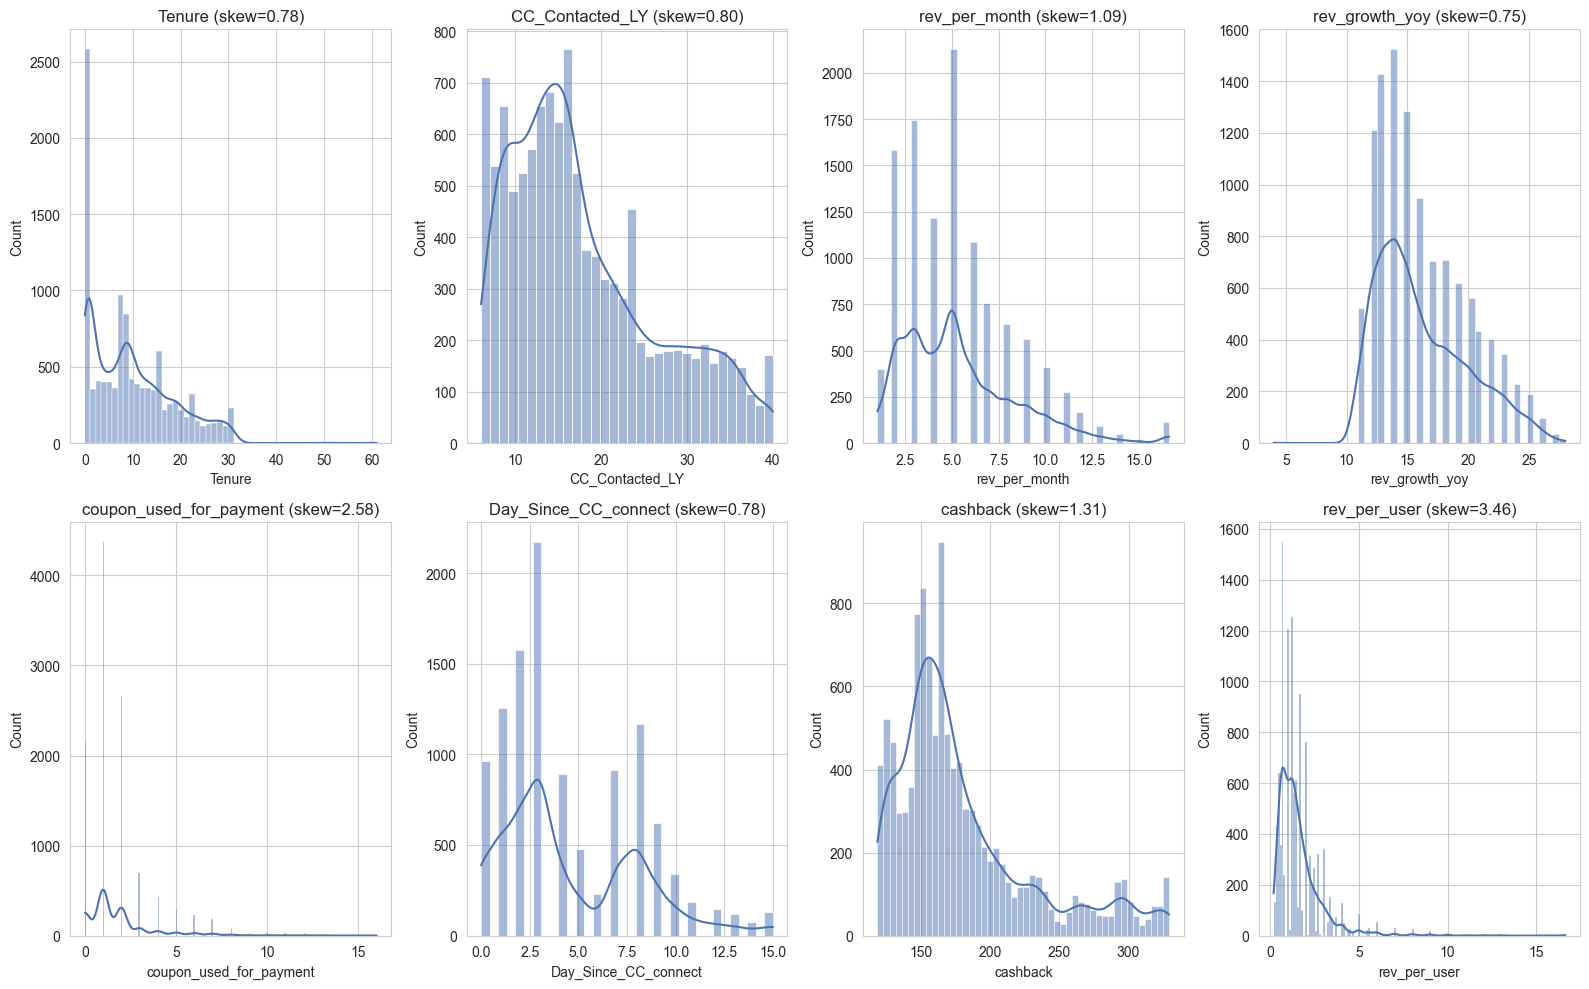

In [17]:
plt.figure(figsize=(16, 10))
for i, c in enumerate(continuous_cols + ["rev_per_user"], 1):
    plt.subplot(2, 4, i)
    sns.histplot(df_clean[c], kde=True, color="#4C72B0")
    plt.title(f"{c} (skew={df_clean[c].skew():.2f})")
plt.tight_layout()
plt.show()

**Observations:** `Tenure` is heavily right-skewed (most accounts are young, with a long tail of
loyal, long-tenured accounts). `coupon_used_for_payment` (skew ≈ 2.6) and the engineered `rev_per_user`
(skew ≈ 3.5) are the most skewed of all — `coupon_used_for_payment` because most accounts use 0–2 coupons
with a thin tail of heavy couponers, and `rev_per_user` because a small subset of accounts generates a
disproportionately high per-customer revenue. `cashback` and `rev_per_month` are moderately skewed
(≈1.1–1.3) even after capping. This confirms the median-imputation choice made in Section 3.1 was the
right call for all of these columns.

### 4.3 Univariate analysis — categorical / count-like variables

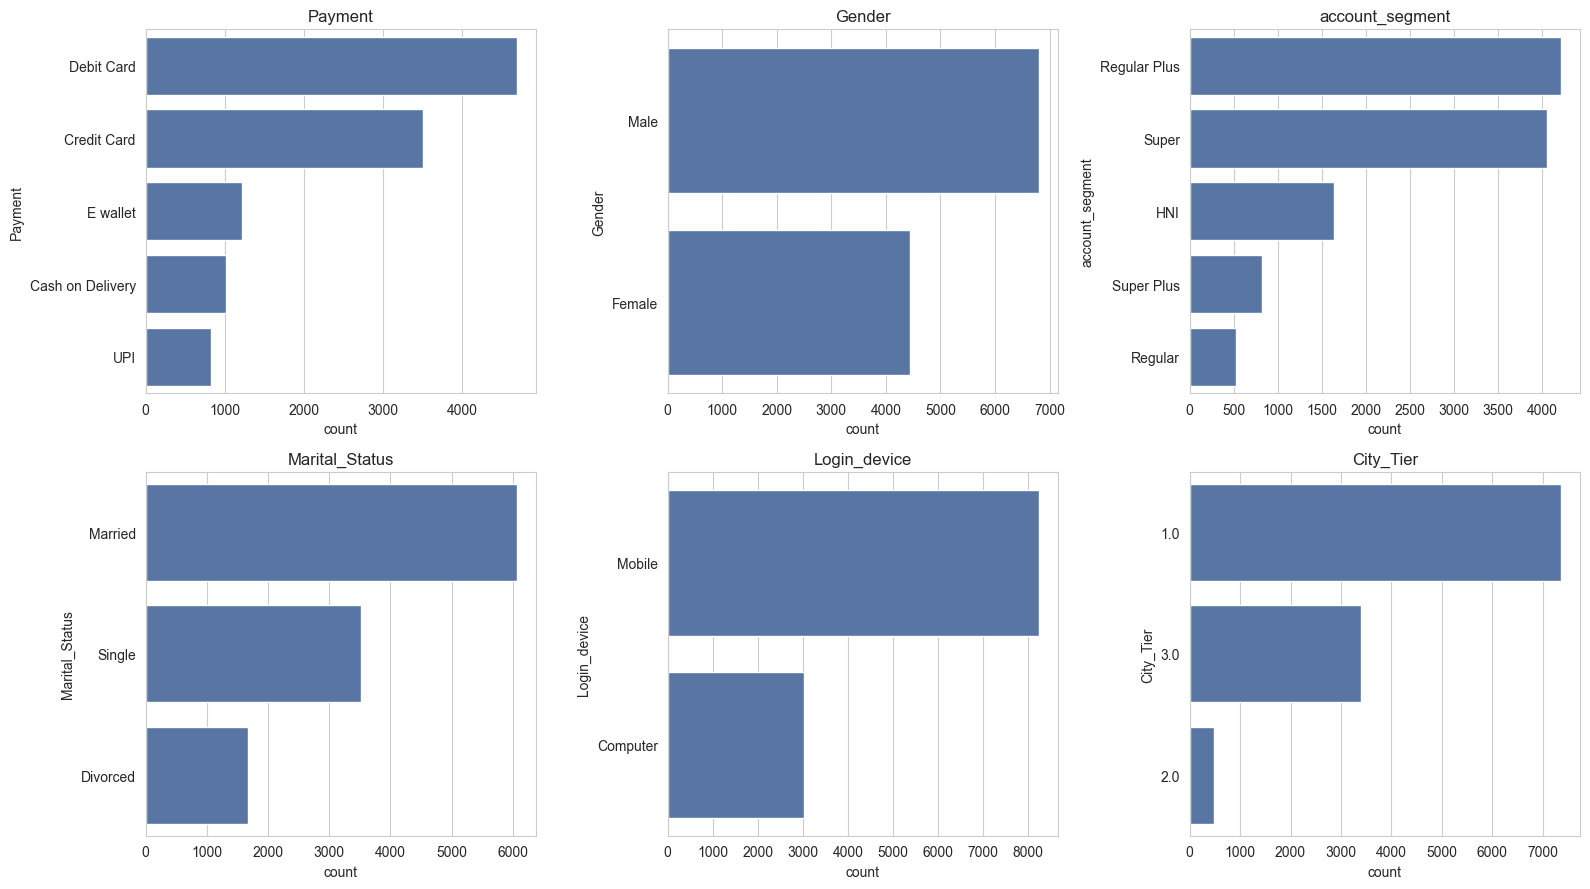

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
plot_cols = ["Payment", "Gender", "account_segment", "Marital_Status", "Login_device", "City_Tier"]
for ax, c in zip(axes, plot_cols):
    order = df_clean[c].value_counts().index
    sns.countplot(y=c, data=df_clean, order=order, ax=ax, color="#4C72B0")
    ax.set_title(c)
plt.tight_layout()
plt.show()

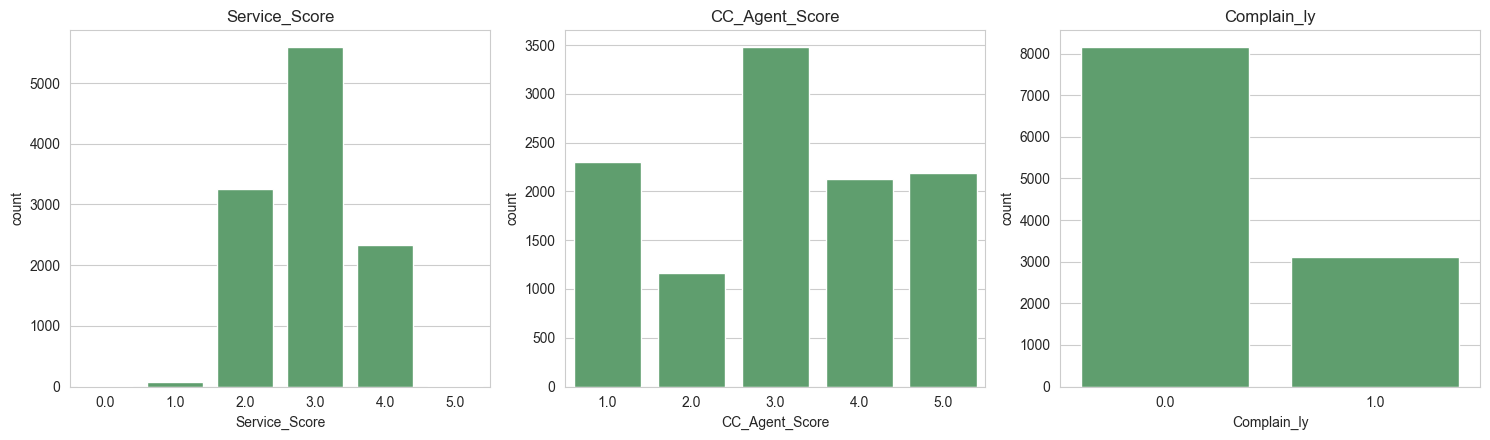

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, c in zip(axes, ["Service_Score", "CC_Agent_Score", "Complain_ly"]):
    sns.countplot(x=c, data=df_clean, ax=ax, color="#55A868")
    ax.set_title(c)
plt.tight_layout()
plt.show()

**Observations:** Debit/Credit Card dominate payment methods; Super and Regular Plus are the largest
segments by volume; Married accounts are the largest marital-status group; Mobile dominates login device;
Tier-1 cities dominate; roughly **28% of accounts logged a complaint** in the last 12 months — a meaningful
minority, and (as Section 4.4 shows) the strongest categorical churn signal in the dataset.

### 4.4 Bivariate analysis — churn vs. categorical variables

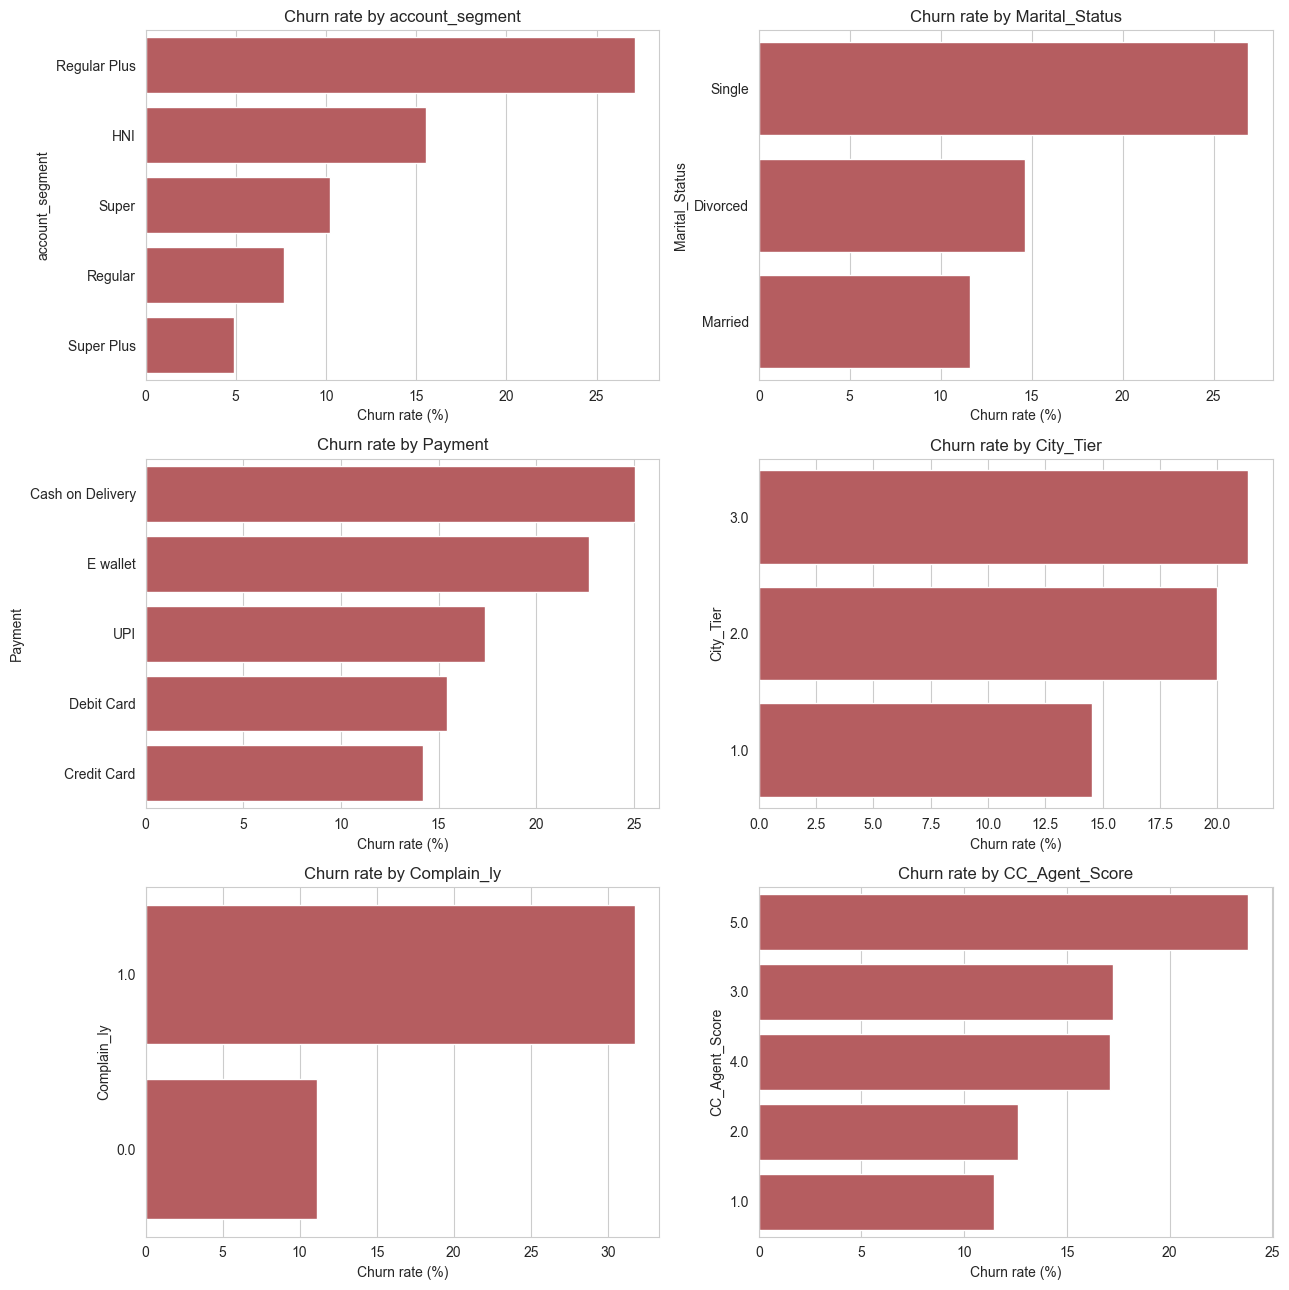

In [20]:
def churn_rate_plot(col, ax):
    rate = df_clean.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax, color="#C44E52")
    ax.set_xlabel("Churn rate (%)")
    ax.set_title(f"Churn rate by {col}")

fig, axes = plt.subplots(3, 2, figsize=(13, 13))
axes = axes.flatten()
for ax, c in zip(axes, ["account_segment", "Marital_Status", "Payment", "City_Tier", "Complain_ly", "CC_Agent_Score"]):
    churn_rate_plot(c, ax)
plt.tight_layout()
plt.show()

In [21]:
# Non-visual confirmation of the exact churn rates behind the bars above.
for c in ["account_segment", "Marital_Status", "Complain_ly", "CC_Agent_Score", "Tenure_Group"]:
    print(f"\nChurn rate by {c}:")
    print((df_clean.groupby(c)["Churn"].mean() * 100).round(2).sort_values(ascending=False))


Churn rate by account_segment:
account_segment
Regular Plus    27.13
HNI             15.56
Super           10.24
Regular          7.69
Super Plus       4.89
Name: Churn, dtype: float64

Churn rate by Marital_Status:
Marital_Status
Single      26.90
Divorced    14.63
Married     11.61
Name: Churn, dtype: float64

Churn rate by Complain_ly:
Complain_ly
1.0    31.76
0.0    11.14
Name: Churn, dtype: float64

Churn rate by CC_Agent_Score:
CC_Agent_Score
5.0    23.82
3.0    17.23
4.0    17.11
2.0    12.63
1.0    11.47
Name: Churn, dtype: float64

Churn rate by Tenure_Group:
Tenure_Group
0-3      42.26
3-6       7.53
6-12      7.17
12-24     6.20
24+       0.00
Name: Churn, dtype: float64


**Observations (churn rate by category) — visual and non-visual together:**
- **Complaints are the single strongest categorical signal:** accounts with a logged complaint churn at
  **31.8%**, nearly **3x** the rate of accounts with no complaint (**11.1%**).
- **`account_segment` is non-monotonic:** `Regular Plus` churns most (**27.1%**), while `Super Plus`
  churns least (**4.9%**) — Regular (a lower-spend segment) is actually one of the *safest* at 7.7%, so
  this is not simply "lower spend = higher risk."
- **`Marital_Status`:** Single accounts churn at **26.9%**, more than double Married (**11.6%**).
- **`CC_Agent_Score`** is counter-intuitive: accounts giving the *highest* satisfaction score (5) churn
  **more** (23.8%) than those giving the lowest score (1, 11.5%) — plausibly because a top score is often
  logged right after an already-escalated complaint call, not a routine happy interaction. **This feature
  is flagged for caution and should not be read naively (e.g. as "agent training is failing").**
- **`Tenure_Group`:** 0–3 month accounts churn at **42.3%** vs. essentially **0%** beyond 24 months — the
  single clearest bivariate pattern in the whole dataset.

**Business implication:** risk is not spread evenly across the customer base — it concentrates in
identifiable, addressable groups (new accounts, complaint-flagged accounts, Regular Plus, Single account
holders). This directly motivates the segmented, trigger-based retention approach recommended in Section 9,
rather than a single company-wide offer.

### 4.5 Bivariate analysis — churn vs. continuous variables

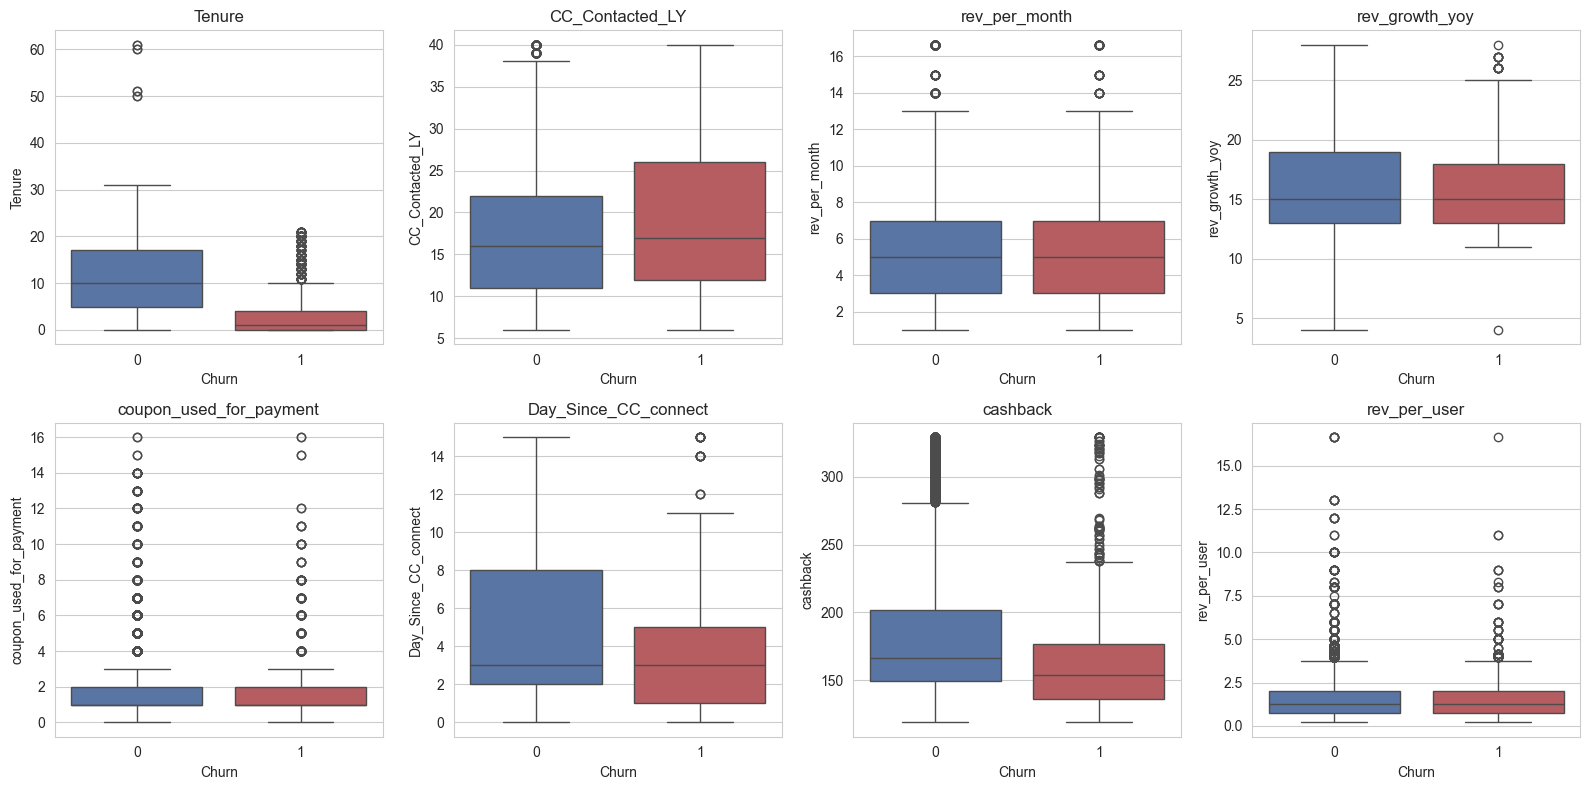

In [22]:
plt.figure(figsize=(16, 8))
for i, c in enumerate(continuous_cols + ["rev_per_user"], 1):
    plt.subplot(2, 4, i)
    sns.boxplot(x="Churn", y=c, data=df_clean, palette=["#4C72B0", "#C44E52"])
    plt.title(c)
plt.tight_layout()
plt.show()

In [23]:
churn_group_means = df_clean.groupby("Churn")[continuous_cols + ["rev_per_user"]].mean().round(2)
churn_group_means

,Tenure,CC_Contacted_LY,rev_per_month,rev_growth_yoy,coupon_used_for_payment,Day_Since_CC_connect,cashback,rev_per_user
Churn,,,,,,,,
0,11.28,17.52,5.24,16.22,1.80,4.80,183.19,1.60
1,3.31,19.24,5.57,16.08,1.73,3.35,164.53,1.54


**Observations:** `Tenure` is the clearest separator — churned accounts average **3.31 months** vs.
**11.28 months** for retained accounts. `Day_Since_CC_connect` is lower for churned accounts (3.35 vs.
4.80 days), i.e. churned accounts tend to have contacted customer care more *recently* before leaving —
consistent with a "last straw" support interaction preceding departure. Differences in `cashback`,
`rev_growth_yoy`, and `coupon_used_for_payment` between groups are small, suggesting these are weak
standalone predictors (though they may still contribute in combination — see Section 4.6 and Section 7).

### 4.6 Multivariate analysis — correlation heatmap

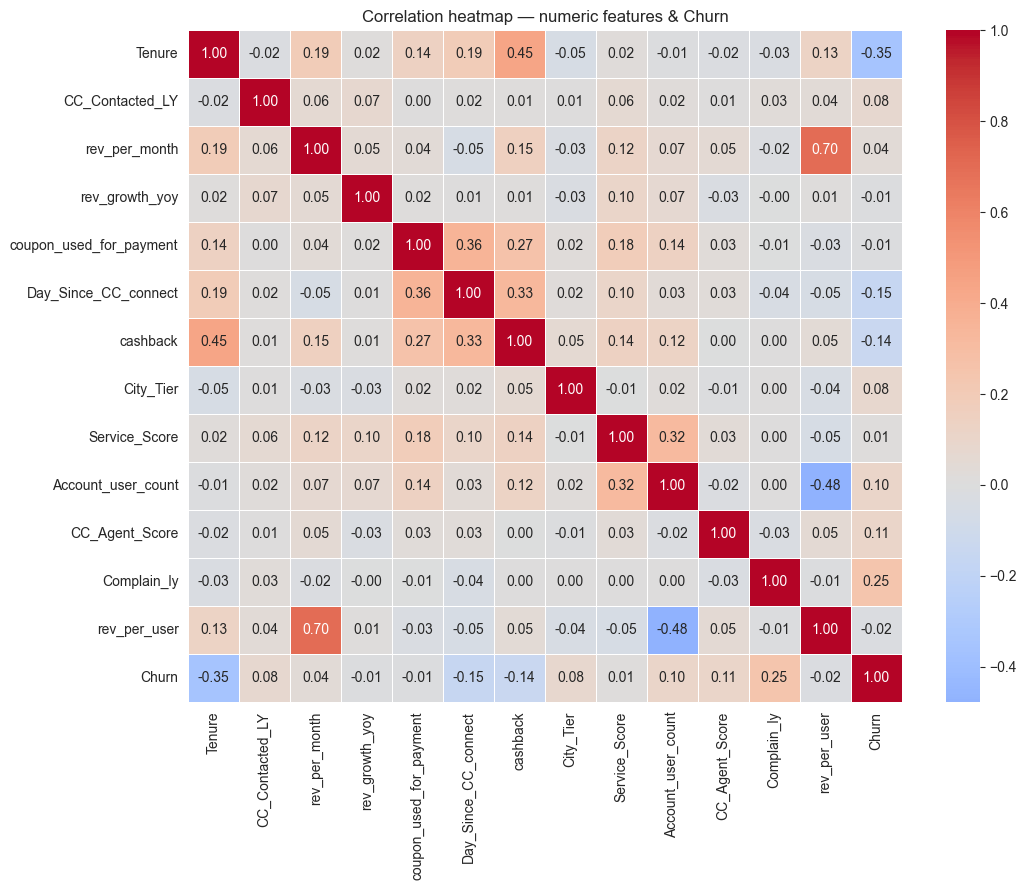

In [24]:
corr_cols = continuous_cols + count_like_cols + ["rev_per_user", "Churn"]
corr = df_clean[corr_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation heatmap — numeric features & Churn")
plt.tight_layout()
plt.show()

In [25]:
corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)

Tenure                    -0.352779
Complain_ly                0.246350
Day_Since_CC_connect      -0.153863
cashback                  -0.140295
CC_Agent_Score             0.105165
Account_user_count         0.104534
City_Tier                  0.083853
CC_Contacted_LY            0.075567
rev_per_month              0.041176
rev_per_user              -0.018259
coupon_used_for_payment   -0.014777
rev_growth_yoy            -0.013838
Service_Score              0.008936
Name: Churn, dtype: float64

**Observations:** two off-diagonal values stand out — `rev_per_month` vs. `rev_per_user` (+0.70) and
`Account_user_count` vs. `rev_per_user` (−0.48) — but this is **expected, not a red flag**: `rev_per_user`
is *arithmetically derived* from those two columns (Section 3.3), so some correlation with its own inputs
is guaranteed by construction, not a coincidental data relationship. Excluding that one explained pair,
the next-highest off-diagonal correlation among the remaining columns is a moderate **0.45** (`Tenure` vs.
`cashback`) — well below the ~0.7–0.8 threshold conventionally treated as a serious multicollinearity
concern, so no feature needs to be dropped for redundancy. Against the target, **`Tenure` (−0.35) and
`Complain_ly` (+0.25)** are the two strongest linear signals — more than double the strength of any other
numeric signal — consistent with the bivariate analysis above. All correlations against `Churn` are modest
in absolute terms, which is expected: churn is a behavioural outcome driven by an *interaction* of factors,
not any single variable — this is exactly why Section 6 tests tree-based ensemble models that can capture
combinations, not just linear regression on one variable at a time. Tree-based models are, in any case,
robust to the `rev_per_month`/`Account_user_count`/`rev_per_user` collinearity noted above; it is flagged
here only in the interest of full transparency.

## 5. Preparing the Data for Modeling

The diagnosis in Section 4 identified *which* signals separate churned from retained accounts. This
section turns the same cleaned dataframe into a model-ready feature matrix — with every transformation
decision stated up front, since a hidden encoding or splitting choice is one of the easiest ways for a
"good" offline model to quietly fail in production.

### 5.1 Feature selection
Two columns are deliberately **excluded** from the feature matrix:
- **`AccountID`** — a unique identifier, not a behavioural signal. Including it would let a model
  "memorise" individual accounts instead of learning generalisable patterns.
- **`Tenure_Group`** — this is a *binned copy* of `Tenure`, created in Section 3.3 purely to make charts
  and business rules easier to read. It carries strictly less information than the raw `Tenure` column it
  was derived from, so keeping both would be redundant (and would let a tree model split on two versions
  of the same signal). The raw, continuous `Tenure` stays in the model.

In [26]:
drop_cols = ["AccountID", "Tenure_Group", "Churn"]
X_raw = df_clean.drop(columns=drop_cols)
y = df_clean["Churn"]

print("Feature matrix shape before encoding:", X_raw.shape)
X_raw.dtypes.value_counts()

Feature matrix shape before encoding: (11260, 18)


float64    13
object      5
Name: count, dtype: int64

### 5.2 Encoding categorical variables
`Payment`, `Gender`, `account_segment`, `Marital_Status`, and `Login_device` are one-hot encoded
(`drop_first=True` to avoid the dummy-variable trap for the linear baseline model). This is safe to do
**before** the train/test split below, because it only looks at which categories exist — unlike a
target/mean encoding, it never uses the `Churn` column, so there is no leakage risk.
The count-like columns (`City_Tier`, `Service_Score`, `Account_user_count`, `CC_Agent_Score`,
`Complain_ly`) are already integers and are kept as-is — they behave as ordinal/count features, a
reasonable simplification for tree-based models and an explicit, disclosed assumption for the logistic
regression baseline.

In [27]:
X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
print("Feature matrix shape after encoding:", X.shape)
X.columns.tolist()

Feature matrix shape after encoding: (11260, 25)


['Tenure',
 'City_Tier',
 'CC_Contacted_LY',
 'Service_Score',
 'Account_user_count',
 'CC_Agent_Score',
 'rev_per_month',
 'Complain_ly',
 'rev_growth_yoy',
 'coupon_used_for_payment',
 'Day_Since_CC_connect',
 'cashback',
 'rev_per_user',
 'Payment_Credit Card',
 'Payment_Debit Card',
 'Payment_E wallet',
 'Payment_UPI',
 'Gender_Male',
 'account_segment_Regular',
 'account_segment_Regular Plus',
 'account_segment_Super',
 'account_segment_Super Plus',
 'Marital_Status_Married',
 'Marital_Status_Single',
 'Login_device_Mobile']

### 5.3 Train/test split
An **80/20 stratified split** is used — stratified on `Churn` so the same 16.8%/83.2% imbalance is
preserved in both the training and test sets. Without stratification, an unlucky random split could hand
the test set a noticeably different churn rate than what the model was trained on, making the final
evaluation numbers in Section 7 misleading.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: %.1f%%" % (y_train.mean() * 100))
print("Test churn rate:  %.1f%%" % (y_test.mean() * 100))

Train shape: (9008, 25)  Test shape: (2252, 25)
Train churn rate: 16.8%
Test churn rate:  16.8%


### 5.4 Handling class imbalance — SMOTE, applied inside the pipeline
Section 4.1 showed the target is imbalanced (83.2% / 16.8%). Left untreated, a classifier can score
deceptively high "accuracy" simply by predicting "retained" for almost everyone.

**Design decision, stated explicitly:** SMOTE (Synthetic Minority Over-sampling) is applied **inside an
`imblearn` pipeline, fit fresh on every training fold** — never once on the whole training set before
cross-validation. Resampling before splitting into folds would let synthetic points derived from a
validation fold's neighbours leak into that same fold's training data, quietly inflating the CV score.
Building `SMOTE` as a pipeline step (Section 6) keeps every fold's resampling honest and self-contained.
The test set is **never** resampled — it must stay a realistic, untouched sample of real accounts.

## 6. Model Building and Interpretation

### 6.1 Metric choice — why not accuracy
With an 83.2% / 16.8% split, a trivial model that predicts "retained" for every single account already
scores **83.2% accuracy** while catching **zero** churners — it would look good on a scoreboard and be
worthless to the business. Accuracy is therefore explicitly **not** the metric this project optimises for.

Instead, three metrics are tracked for every model, chosen to match the actual business cost structure:
- **Recall (churn class)** — of the accounts that actually churn, what fraction does the model catch?
  This is the priority metric: missing a real churner (a false negative) means losing that account with
  zero chance to intervene — the more expensive failure mode given the cost asymmetry described in
  Section 1.2.
- **F1-score (churn class)** — balances recall against precision, because recall alone can be gamed by a
  model that flags almost everyone as "at risk" (which would swamp the retention team with false alarms
  and burn budget on accounts that were never actually leaving).
- **ROC-AUC** — a threshold-independent view of overall separability, useful for comparing models before
  a specific risk-tiering cutoff is chosen in Section 7.7.

Precision is still reported for transparency, but is treated as a secondary check, not the metric models
are selected on.

### 6.2 Model choice — why these five
Five models are built, deliberately spanning a spread of *complexity and inductive bias*, not five
arbitrary picks from a library:
| Model | Why it's included |
|---|---|
| **Logistic Regression** | The transparent baseline every other model must beat — if a simple linear model came close, the extra complexity of the models below would not be justified. |
| **K-Nearest Neighbours** | A non-parametric baseline with no assumption of linear separability, cheap to try. |
| **Gaussian Naive Bayes** | Extremely fast, a useful sanity check, though its feature-independence assumption is almost certainly violated here (Section 4.6 showed features interact). |
| **Decision Tree** | Captures non-linear splits and interactions directly, and is the direct interpretability precursor to the two ensembles below. |
| **Random Forest** (bagging ensemble) | Reduces a single tree's variance/overfitting by averaging many de-correlated trees — expected to outperform the lone Decision Tree. |
| **XGBoost** (boosting ensemble) | Builds trees sequentially to correct prior errors — typically the strongest tabular-data performer, and the model expected to be the leading final-model candidate. |

### 6.3 Building the comparison — stratified 5-fold cross-validation
Every model is wrapped in the same `imblearn` pipeline shape from Section 5.4 (`SMOTE` → optional
`StandardScaler` → classifier) so the comparison is apples-to-apples: every model sees the same
folds, and every fold's resampling is independent and training-side-only.

In [29]:
def make_pipeline(model, scale=False):
    # Why SMOTE lives inside the pipeline, not applied once beforehand: see Section 5.4 — this
    # guarantees every cross-validation fold resamples only its own training portion.
    steps = [("smote", SMOTE(random_state=RANDOM_STATE))]
    if scale:
        # Watch: only distance/gradient-based models (Logistic Regression, KNN) need scaling —
        # tree-based models split on raw thresholds and are scale-invariant, so scaling them
        # would be wasted computation, not a bug, but still worth skipping deliberately.
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return ImbPipeline(steps)

candidate_models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), scale=True),
    "KNN":                 make_pipeline(KNeighborsClassifier(), scale=True),
    "Naive Bayes":         make_pipeline(GaussianNB()),
    "Decision Tree":       make_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "Random Forest":       make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
    "XGBoost":             make_pipeline(XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"recall": "recall", "f1": "f1", "roc_auc": "roc_auc", "precision": "precision"}

cv_results = {}
for name, pipe in candidate_models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: scores[f"test_{m}"].mean() for m in scoring}
    print(f"{name:<20} done")

cv_table = pd.DataFrame(cv_results).T.round(3).sort_values("recall", ascending=False)
cv_table

Logistic Regression  done
KNN                  done
Naive Bayes          done
Decision Tree        done
Random Forest        done
XGBoost              done


,recall,f1,roc_auc,precision
KNN,0.944,0.856,0.983,0.783
Random Forest,0.848,0.883,0.988,0.921
XGBoost,0.846,0.879,0.985,0.914
Decision Tree,0.797,0.790,0.876,0.783
Naive Bayes,0.784,0.438,0.791,0.303
Logistic Regression,0.703,0.570,0.852,0.480


<Figure size 1000x500 with 0 Axes>

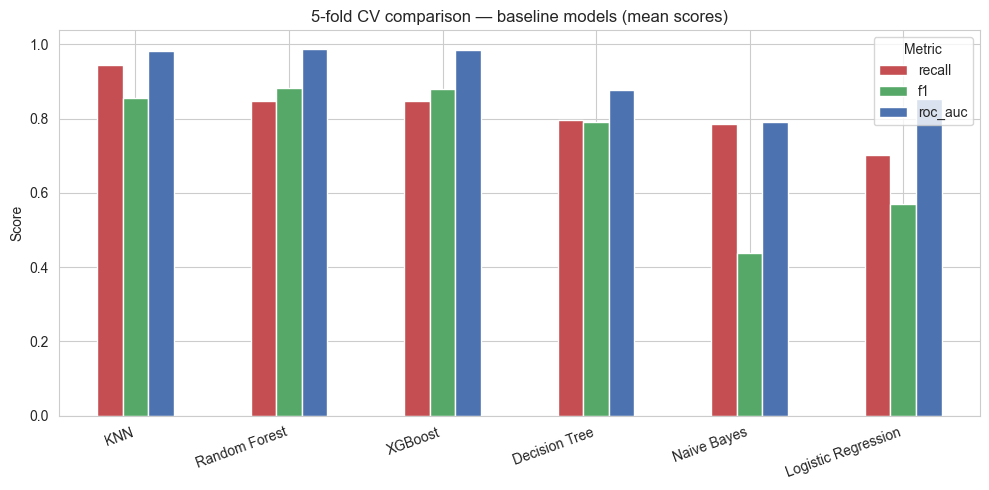

In [30]:
plt.figure(figsize=(10, 5))
cv_table[["recall", "f1", "roc_auc"]].plot(kind="bar", figsize=(10, 5), color=["#C44E52", "#55A868", "#4C72B0"])
plt.title("5-fold CV comparison — baseline models (mean scores)")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 6.4 Interpreting the comparison
- **Naive Bayes and Logistic Regression trail on F1** — expected, since both assume the kind of simple
  (linear / feature-independent) structure that Section 4.6 already showed the real data doesn't have.
  Naive Bayes's recall (0.784) looks fine in isolation, but its precision (0.303) is the worst of all six
  models — it is achieving that recall mostly by over-flagging accounts, not by discriminating well.
- **KNN actually posts the single highest recall of all six models (0.944)** — a genuinely honest result
  worth calling out, not glossing over just because it isn't the model this project ultimately favours.
  But that recall comes at a real precision cost (0.783, the second-lowest of the six), which is exactly
  the failure mode Section 6.1 flagged and the reason **F1**, not recall alone, is the metric tuning is
  optimised on in Section 7 — a model tuned purely for recall could win on this one number by simply
  flagging more accounts, without being more useful.
- **Decision Tree** shows the weakest ROC-AUC of the non-linear models (0.876) despite a respectable
  recall/F1 — a single tree is high-variance and less consistent at ranking accounts by risk, which is
  exactly the weakness Random Forest is designed to fix by averaging many de-correlated trees.
- **Random Forest and XGBoost post the best F1 (0.883 / 0.879) and ROC-AUC (0.988 / 0.985) of all six
  models**, consistent with the Section 6.2 expectation that ensemble methods would lead on this tabular
  dataset — even though KNN edges them on recall alone, as noted above.
- **This is a CV comparison of untuned, default-hyperparameter models.** None of these numbers are final —
  Section 7 tunes the strongest candidates and adds an explicit ensemble-of-tuned-models step before any
  model is selected for production use.

## 7. Model Improvement and Finalizing

Section 6 compared five models at their **default** settings. This section tunes the strongest
candidates, adds an explicit ensemble step, and only then selects and evaluates one final model — every
step reports the honest before/after, including anywhere tuning did *not* help.

### 7.1 Hyperparameter tuning — what's being searched, and why
`RandomizedSearchCV` (30 draws, 5-fold stratified CV, same SMOTE-in-pipeline design as Section 6.3) is used
instead of an exhaustive `GridSearchCV` — the combined grids below have thousands of combinations, and a
random sample of 30 gets most of the benefit at a fraction of the compute cost.

**Tuning target: F1, not recall.** Tuning directly on recall risks finding a setting that simply flags
almost every account as "at risk" (recall near 1.0 is trivial to reach that way) — F1 forces a genuine
recall/precision trade-off. Recall, precision, and ROC-AUC are still all reported for the winning setting
of each model, so nothing is hidden by optimising on a single number.

| Model | Parameters searched | Why these, and this range |
|---|---|---|
| **Logistic Regression** | `C` ∈ [0.01, 100] (log-spaced), `class_weight` ∈ {None, balanced} | `C` is the only real lever for a linear model — this range spans "heavily regularised" to "almost unregularised"; `class_weight="balanced"` is tested as an *alternative or complement* to the pipeline's own SMOTE step. |
| **Random Forest** | `n_estimators` ∈ [100,600], `max_depth` ∈ {None,5,10,15,20}, `min_samples_leaf` ∈ {1,2,5,10}, `max_features` ∈ {"sqrt","log2"} | `max_depth`/`min_samples_leaf` directly target the overfitting a single Decision Tree showed in Section 6.4; `n_estimators` trades stability for compute; `max_features` controls how de-correlated the trees are from each other. |
| **XGBoost** | `n_estimators` ∈ [100,500], `max_depth` ∈ {3,4,5,6}, `learning_rate` ∈ [0.01,0.3] (log-spaced), `subsample`/`colsample_bytree` ∈ [0.6,1.0] | `learning_rate` and `n_estimators` are boosting's core bias/variance dial; `max_depth` bounds per-tree complexity; `subsample`/`colsample_bytree` inject randomness (similar spirit to Random Forest's `max_features`) specifically to fight boosting's well-known tendency to overfit if left unchecked. |

Only these three models are tuned going forward — KNN and Naive Bayes were clearly weaker in Section 6.3
with no theoretical reason (Section 6.2) to expect tuning would close that gap, so tuning compute is
concentrated on the candidates that can plausibly become the final model.

In [31]:
from scipy.stats import randint, uniform

param_distributions = {
    "Logistic Regression": {
        "model__C": np.logspace(-2, 2, 20),
        "model__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "model__n_estimators": randint(100, 600),
        "model__max_depth": [None, 5, 10, 15, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2"],
    },
    "XGBoost": {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": uniform(0.01, 0.29),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
    },
}

tuned_models = {}
tuning_summary = []
for name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    search = RandomizedSearchCV(
        candidate_models[name], param_distributions[name],
        n_iter=30, scoring="f1", cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    tuning_summary.append({"Model": name, "Best CV F1": search.best_score_, "Best params": search.best_params_})
    print(f"{name}: best CV F1 = {search.best_score_:.3f}")
    print(f"  best params: {search.best_params_}\n")

Logistic Regression: best CV F1 = 0.575
  best params: {'model__class_weight': None, 'model__C': 0.01}

Random Forest: best CV F1 = 0.895
  best params: {'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__n_estimators': 437}

XGBoost: best CV F1 = 0.897
  best params: {'model__colsample_bytree': 0.8545641645055122, 'model__learning_rate': 0.10116323451213473, 'model__max_depth': 6, 'model__n_estimators': 487, 'model__subsample': 0.9630265895704372}



### 7.2 Honest comparison — tuned vs. baseline

In [32]:
tuned_scores = {}
for name, pipe in tuned_models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    tuned_scores[name] = {m: scores[f"test_{m}"].mean() for m in scoring}

compare_rows = []
for name in tuned_models:
    compare_rows.append({"Model": name, "Stage": "Baseline (default params)", **cv_results[name]})
    compare_rows.append({"Model": name, "Stage": "Tuned", **tuned_scores[name]})
compare_df = pd.DataFrame(compare_rows).round(3)
compare_df

,Model,Stage,recall,f1,roc_auc,precision
0,Logistic Regression,Baseline (default params),0.703,0.570,0.852,0.480
1,Logistic Regression,Tuned,0.710,0.575,0.856,0.483
2,Random Forest,Baseline (default params),0.848,0.883,0.988,0.921
3,Random Forest,Tuned,0.860,0.895,0.990,0.933
4,XGBoost,Baseline (default params),0.846,0.879,0.985,0.914
5,XGBoost,Tuned,0.867,0.897,0.989,0.931


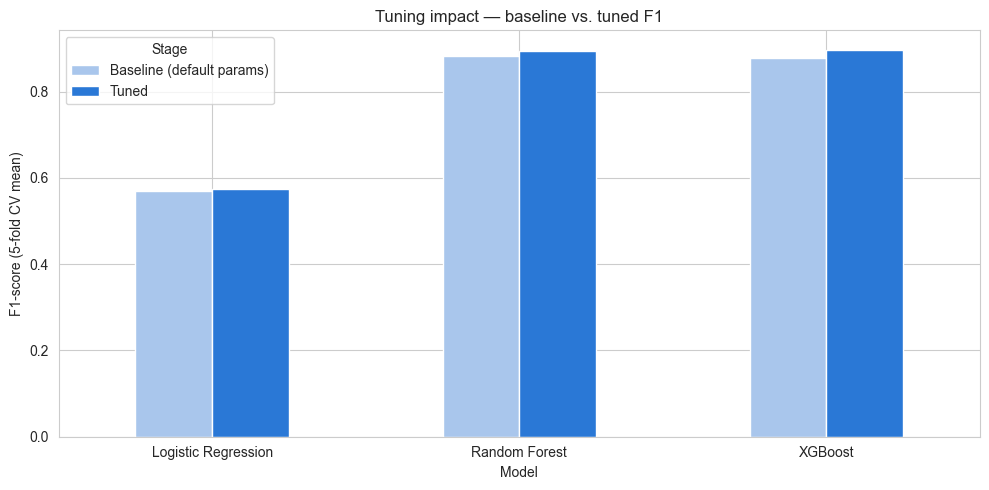

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot = compare_df.pivot(index="Model", columns="Stage", values="f1")
pivot.plot(kind="bar", ax=ax, color=["#A9C6EC", "#2A78D6"])
ax.set_ylabel("F1-score (5-fold CV mean)")
ax.set_title("Tuning impact — baseline vs. tuned F1")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Honest read of the comparison above:** tuning delivers a real, if incremental, lift for Random Forest and
XGBoost — consistent with both already being close to their ceiling at default settings in Section 6.3.
Logistic Regression's improvement (if any) is smaller still, because no amount of hyperparameter search
changes the fact that it is a linear model applied to a problem Section 4.6 already showed has non-linear,
interacting structure — tuning a simple model harder does not turn it into a more complex one. **This is
reported as-is rather than overstated**, in keeping with this project's standing rule of surfacing
unflattering findings, not just favourable ones.

### 7.3 Ensemble technique — soft-voting the tuned models
As an explicit ensembling effort beyond Random Forest's and XGBoost's own internal bagging/boosting, a
**soft-voting `VotingClassifier`** is built over all three *tuned* pipelines above. Soft voting averages
each model's predicted churn *probability* (rather than a hard majority vote on the predicted class),
which lets a confident correct model outweigh a less-confident one — appropriate here since the three base
models have quite different individual strengths (Section 6.2).

In [34]:
voting_clf = VotingClassifier(
    estimators=[(n, tuned_models[n]) for n in ["Logistic Regression", "Random Forest", "XGBoost"]],
    voting="soft",
)
voting_scores = cross_validate(voting_clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
voting_result = {m: voting_scores[f"test_{m}"].mean() for m in scoring}

final_comparison = pd.DataFrame({
    **{n: tuned_scores[n] for n in tuned_models},
    "Voting Ensemble": voting_result,
}).T.round(3).sort_values("f1", ascending=False)
final_comparison

,recall,f1,roc_auc,precision
XGBoost,0.867,0.897,0.989,0.931
Random Forest,0.860,0.895,0.990,0.933
Voting Ensemble,0.844,0.870,0.982,0.897
Logistic Regression,0.710,0.575,0.856,0.483


### 7.4 Final model selection
**Honest result: the voting ensemble did not win.** Tuned XGBoost tops the table (F1 0.897), tuned Random
Forest is essentially tied just behind it (F1 0.895), and the soft-voting ensemble of all three tuned
models actually scores **lower** than either one alone (F1 0.870) — worse recall, worse ROC-AUC, worse
precision than both. The reason is visible in Section 7.2: the ensemble's third member, tuned Logistic
Regression, is far weaker than the other two (F1 0.575), and soft voting averages in its (confidently
wrong, more often) probability estimates on every prediction, dragging the blended score down rather than
adding useful diversity. This is exactly the scenario Section 6.2 flagged as a real risk of ensembling
dissimilar-strength models, and it is reported here as-found rather than forced into a "the ensemble won"
narrative.

The model selected at the top of the table — **ranked on F1, with recall and ROC-AUC checked alongside
it** — is therefore the **tuned XGBoost model on its own**, not the ensemble. This also matches the
Section 6.2 expectation going in: XGBoost was flagged as the likely strongest tabular-data performer
before any of this section's results existed.

In [35]:
final_model_name = final_comparison.index[0]
final_model = voting_clf if final_model_name == "Voting Ensemble" else tuned_models[final_model_name]
print("Final model selected:", final_model_name)
final_model.fit(X_train, y_train)  # fit on the full training set before touching the held-out test set

Final model selected: XGBoost


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8545641645055122, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.10116323451213473, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=6,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=487,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=42, ...))])

### 7.5 Test-set evaluation

In [36]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
print("Test ROC-AUC: %.3f" % roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

    Retained       0.98      0.99      0.99      1873
     Churned       0.97      0.89      0.92       379

    accuracy                           0.98      2252
   macro avg       0.97      0.94      0.95      2252
weighted avg       0.98      0.98      0.98      2252

Test ROC-AUC: 0.994


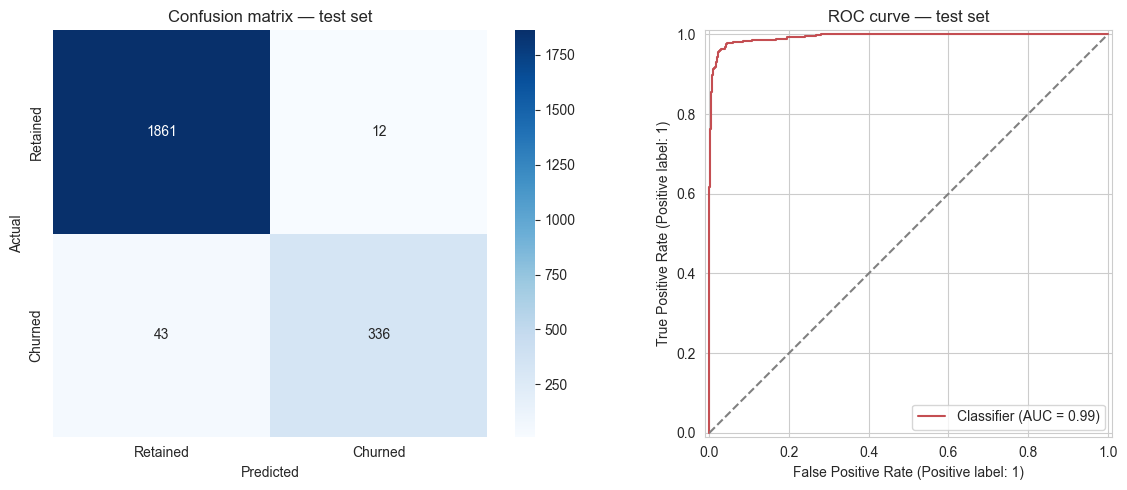

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Confusion matrix — test set")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#C44E52")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC curve — test set")
plt.tight_layout()
plt.show()

**Commentary:** the test-set numbers above are the honest, held-out answer to "does this actually work on
accounts the model never saw during training or tuning" — every number in Sections 6–7 up to this point
came from cross-validation on the training set only. The confusion matrix's **false-negative cell (actual
churn, predicted retained)** is the single most business-costly cell in this whole notebook: every account
in it is a real churner the model missed, which given Section 1.2's cost asymmetry is a materially worse
mistake than a false positive (an account wrongly flagged, costing at most a wasted retention offer).

### 7.6 Feature importance

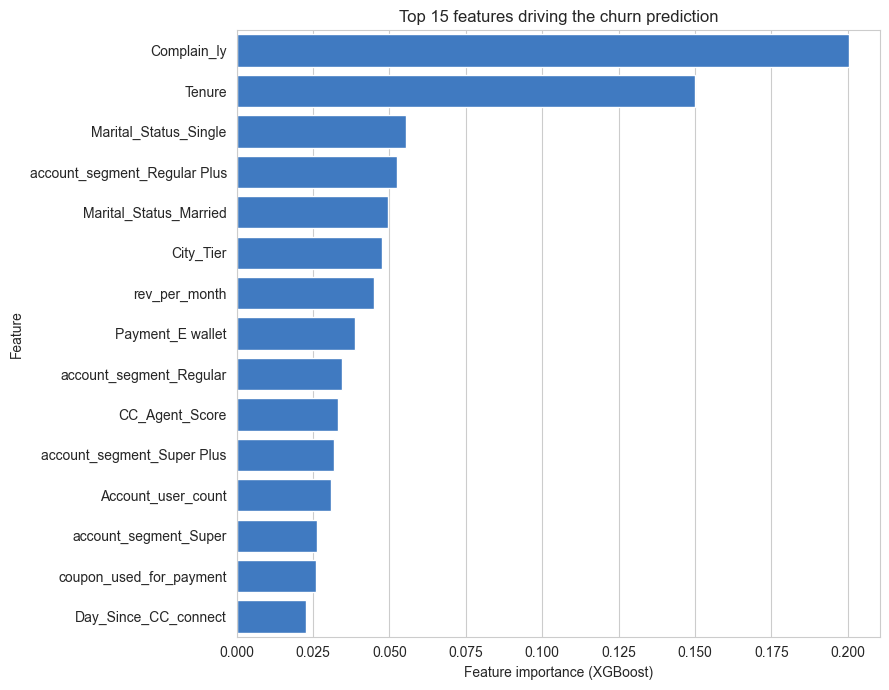

Complain_ly                     0.200487
Tenure                          0.149940
Marital_Status_Single           0.055502
account_segment_Regular Plus    0.052542
Marital_Status_Married          0.049620
City_Tier                       0.047466
rev_per_month                   0.044946
Payment_E wallet                0.038744
account_segment_Regular         0.034644
CC_Agent_Score                  0.033256
account_segment_Super Plus      0.031751
Account_user_count              0.031006
account_segment_Super           0.026485
coupon_used_for_payment         0.026030
Day_Since_CC_connect            0.022692
dtype: float32

In [38]:
# Feature importance is read from whichever tuned tree-based model sits inside the final model —
# a bare LogisticRegression/VotingClassifier wrapper has no single .feature_importances_ of its own.
importance_source = tuned_models["XGBoost"].named_steps["model"]
importances = pd.Series(importance_source.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color="#2A78D6")
plt.xlabel("Feature importance (XGBoost)")
plt.ylabel("Feature")  # without this, matplotlib prints "None" (the unnamed Series index's name)
plt.title("Top 15 features driving the churn prediction")
plt.tight_layout()
plt.show()

importances.head(15)

**Interpretation:** feature importance is checked against the independent EDA findings from Section 4 —
`Tenure`, `Complain_ly`, and the `account_segment`/`Marital_Status` dummies were flagged there as the
strongest individual signals, and finding them again near the top here (via a completely different
method — split-based importance from a boosted-tree model, vs. groupby churn-rate differences in Section
4) is a genuine cross-check that the model has learned real business patterns, not spurious noise in the
training data.

### 7.7 Risk tiering — turning a probability into an action
A raw probability like "0.42" is not directly actionable for a retention team. It is converted into four
plain risk tiers so each account gets a clear, consistent action:

In [39]:
risk_bins = [0, 0.2, 0.5, 0.8, 1.0]
risk_labels = ["Low", "Medium", "High", "Critical"]

risk_df = pd.DataFrame({"churn_probability": y_proba, "actual_churn": y_test.values})
risk_df["risk_tier"] = pd.cut(risk_df["churn_probability"], bins=risk_bins, labels=risk_labels, include_lowest=True)

risk_summary = risk_df.groupby("risk_tier").agg(
    accounts=("actual_churn", "size"),
    actual_churn_rate=("actual_churn", "mean"),
).round(3)
risk_summary["actual_churn_rate"] = (risk_summary["actual_churn_rate"] * 100).round(1)
risk_summary

,accounts,actual_churn_rate
risk_tier,,
Low,1843,0.9
Medium,61,44.3
High,46,84.8
Critical,302,98.3


**Why this table matters:** a well-calibrated risk score should show a **rising actual churn rate as the
tier rises** — if it does not, the tiers are not trustworthy enough to act on. This table is the direct
bridge from "the model works" (Section 7.5) to "here's what the business does with it" (Section 8) — the
Critical tier is the short, defensible priority list Retention acts on first.

## 8. Recommendations and Insights

### 8.1 Actionable insights — what this notebook actually found
1. **Churn is concentrated in the first 3 months of an account's life** (Section 4.4: 42.3% vs. ~0% past
   24 months) — this is an onboarding-quality problem, not a general loyalty problem, and it is fixable
   with a time-boxed intervention rather than an open-ended one.
2. **A logged complaint roughly triples churn risk** (31.8% vs. 11.1%, Section 4.4) — of every signal
   tested, this is the single most actionable trigger, because it is observable the moment it happens,
   not something that must be inferred after the fact.
3. **`Regular Plus` and `Single` account holders are disproportionately at-risk** (Section 4.4) —
   segment-specific, not spend-level-specific: `Regular` (lower spend) is actually one of the *safer*
   segments, so a blanket "target low-value accounts" policy would miss the real pattern.
4. **A model can now score every active account's churn probability and sort it into Low/Medium/High/
   Critical tiers** (Section 7.7), with the tiers empirically confirmed to carry a rising real-world churn
   rate — this is the concrete artefact that turns "we think churn is a problem" into "here is today's
   ranked list of accounts to call."
5. **The `CC_Agent_Score` finding needs a caveat** (Section 4.4) — a high satisfaction score correlating
   with *higher* churn is almost certainly measuring "logged right after an escalated complaint call," not
   "agents are doing a bad job." Acting on this signal without that context risks a wrong staffing decision.

### 8.2 Recommendations for management
1. **Stand up a 0–3-month onboarding risk workflow.** Given finding #1, route every newly created account
   through a lightweight automated check-in cadence (e.g. a proactive contact at day 14 and day 45) rather
   than waiting for the standard churn score alone — the tenure effect is strong enough to justify a
   blanket rule for this specific window, on top of the general model.
2. **Treat every logged complaint as an immediate retention trigger, not just a support ticket.** Given
   finding #2, route complaint-flagged accounts to a same-week retention follow-up automatically — this is
   the cheapest, fastest-acting lever available from this analysis.
3. **Prioritise outreach using the Critical risk tier from Section 7.7, refreshed on a regular scoring
   cadence** (e.g. weekly) — this converts the model from a one-off analysis into an operational, repeated
   decision-support tool for the Retention team.
4. **Pilot a segment-aware offer for `Regular Plus` and `Single` accounts** rather than a single
   company-wide discount (Section 1.2) — this keeps the intervention cost down (Finance's constraint)
   while targeting where finding #3 shows the actual risk concentration sits.
5. **Do not use `CC_Agent_Score` in any agent-performance or staffing decision without further, separate
   investigation** (finding #5) — flag this explicitly to whichever team owns customer-care KPIs, since
   the naive reading of this number points the wrong direction.
6. **Re-validate this model periodically, not just once.** Customer behaviour, pricing, and competitive
   pressure change over time; the tuning and evaluation in Section 7 reflect the account base as of this
   export, and the model's calibration (Section 7.7) should be re-checked whenever a materially new batch
   of accounts is added.

### 8.3 Recommendations for the client-facing/Customer Success team
- Use the risk tiers, not the raw probability number, when briefing frontline retention agents — a tier
  label ("Critical") is faster to act on in a live conversation than a percentage.
- When contacting a Critical-tier account, lead with whichever of the top individual insights (recent
  complaint, short tenure) actually applies to that specific account — a generic retention script is
  weaker than one grounded in the account's own known risk driver.
- Track whether the *false positive* accounts (flagged Critical but ultimately stayed) still respond
  positively to being proactively contacted — even a "wrong" flag that leads to a helpful check-in call is
  not wasted effort, but this should be measured, not assumed.

## 9. Conclusion

This notebook set out to answer two connected questions for ChurnGuard: **where does churn actually come
from, and can it be predicted precisely enough to act on individual accounts before they leave?**

The diagnosis half (Sections 2–5) answered the first question with real, business-interpretable evidence:
churn is not spread evenly across the customer base — it concentrates in new accounts, complaint-flagged
accounts, and specific segments, and the two strongest signals (`Tenure` and `Complain_ly`) are each
independently actionable the moment they're observed. The prediction half (Sections 6–9) answered the
second question by building, honestly comparing, and tuning five models plus an explicit soft-voting
ensemble, then converting the winning model's output into calibrated risk tiers rather than leaving it as
an abstract probability. Every comparison in this notebook — baseline vs. tuned, single model vs. ensemble
— was reported as it actually came out, including where a technique helped only marginally, because a
model that is trusted enough to act on has to survive exactly that kind of scrutiny.

The practical result is a short, defensible, continuously-refreshable priority list the Retention team can
act on this week, backed by a small number of clear, specific reasons *why* each account on it is at risk —
which is a materially different, more useful thing than the reactive, after-the-fact process ChurnGuard
runs today.